In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
import numpy as np
import pandas as pd
import glob
import tqdm

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


In [3]:
client = Client()

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecust

In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40805,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39879,Total threads: 2
Dashboard: /proxy/46603/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:46149,


## Workflow to generate the below data
* Run the sea breeze identification (`barra_c/filter_jobs/filter_F_driver.sh`)
* Define the shapes of the coastal zones for defining sea breeze days for each offshore wind area (`coastal_shapes.py`)
* Resample to daily max (in local time) and define SB days for each REZ (`composite_analysis/daily_resample.sh`)
* Composite variables for SB days and non SB days in a set of regions, on a monthly basis, and average to seasonal (`sea_breeze_composite_*.sh`)

In [5]:
def load_composite(region):

    sb = []
    nonsb = []
    for season in ["ANN","DJF","MAM","JJA","SON"]:
        try:
            sb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_sb_composite_"+region+"_"+season+".nc",chunks={}))
            nonsb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_nonsb_composite_"+region+"_"+season+".nc",chunks={}))
        except:
            sb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_sb_composite_"+region+"_"+season+".zarr",chunks={}))
            nonsb.append(xr.open_dataset("/g/data/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_nonsb_composite_"+region+"_"+season+".zarr",chunks={}))
    
    sb = xr.concat(sb,dim="season").persist()
    nonsb = xr.concat(nonsb,dim="season").persist()
    
    sb["season"] = ["ANN","DJF","MAM","JJA","SON"]
    nonsb["season"] = ["ANN","DJF","MAM","JJA","SON"]

    return sb, nonsb

gipps_sb, gipps_non_sb = load_composite("gipps")
bunbury_sb, bunbury_non_sb = load_composite("bunbury")
illawarra_sb, illawara_non_sb = load_composite("illawara")
newcastle_sb, newcastle_non_sb = load_composite("newcastle")
sa_sb, sa_non_sb = load_composite("sa")
southern_sb, southern_non_sb = load_composite("southern")
tas_sb, tas_non_sb = load_composite("tas")

In [6]:
#Load sb days for each region

def read_csv(path):

    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    return df.set_index("time").loc[slice("1979-01-01","2024-12-31 23:00")]

#Plot demand on sb days and non sb days for each region
bunbury_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/bunbury.csv")
gipps_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/gipps.csv")
illawara_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/illawara.csv")
newcastle_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/newcastle.csv")
sa_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/sa.csv")
southern_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/southern.csv")
tas_sb_days = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/tas.csv")

In [7]:
shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=southern_sb.lat,lon=southern_sb.lon)
shapes_bunbury = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=bunbury_sb.lat,lon=bunbury_sb.lon)

In [8]:
# shapes_bunbury.bunbury_landsea.plot()
# xr.plot.contour((shapes_bunbury["rez_mask"]==43))

#Gipps=27
#Illawarra=19
#Newcastle=18
#Southern=28
#SA=38
#Tas=42
#Bunbury onshore=43
#Bunbury offshore=44

In [9]:
def load_nemosis(path,region=None):

    df = pd.read_csv(path,skiprows=[0])
    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df[["SETTLEMENTDATE","REGIONID","TOTALDEMAND"]].dropna()
    df = df.drop_duplicates(["SETTLEMENTDATE","REGIONID"])
    
    if region is None:
        df = df.groupby("SETTLEMENTDATE").sum()
        df = df.loc[df.index.minute == 0]
        return df[["TOTALDEMAND"]]
    else:
        df = df[df["REGIONID"]==region]
        df = df.set_index("SETTLEMENTDATE").sort_index()
        df = df.loc[df.index.minute == 0]
        return df

nemosis_files = np.sort(glob.glob("/g/data/ng72/ab4502/nemosis/*.CSV"))
demand_nsw = pd.concat([load_nemosis(f,"NSW1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_vic = pd.concat([load_nemosis(f,"VIC1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_sa = pd.concat([load_nemosis(f,"SA1") for f in tqdm.tqdm(nemosis_files)],axis=0)
demand_tas = pd.concat([load_nemosis(f,"TAS1") for f in tqdm.tqdm(nemosis_files)],axis=0)

100%|██████████| 122/122 [00:44<00:00,  2.77it/s]


In [10]:
def load_wa_demand(path):
    df = pd.read_csv(path)
    df = df.set_index(pd.to_datetime(df["Trading Interval"])).rename(columns={"Operational Demand (MW)":"TOTALDEMAND"})[["TOTALDEMAND"]]
    df = df.loc[df.index.minute == 0]
    df = df.drop_duplicates()
    return df


wa_demand_files = np.sort(glob.glob("/g/data/ng72/ab4502/wa_demand/operational-demand-*.csv"))
demand_wa = pd.concat([load_wa_demand(f) for f in tqdm.tqdm(wa_demand_files)],axis=0)

100%|██████████| 10/10 [00:01<00:00,  6.46it/s]


In [11]:
def plot(mask,sb,non_sb,var,season="DJF",title="",demand=None,sb_days=None,letter="",ylab1=False,ylab2=False,ylim=[0.4,1]):
    l1=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:blue")
    l2=xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:orange")
    plt.title(title)

    plt.ylim(ylim)

    plt.xlabel("")
    plt.gca().grid(ls=":")

    if ylab1:
        plt.ylabel("Capacity Factor")

    plt.gca().text(0.05,0.85,letter+")",transform=plt.gca().transAxes,fontdict={"size":"16"})


    
    if demand is not None:

        months = {"DJF":[12,1,2], "MAM":[3,4,5], "JJA":[6,7,8], "SON":[9,10,11],"ANN":np.arange(1,13)}
        demand = demand.iloc[(np.in1d(demand.index.month,months[season])) & (demand.index.year >= 2010) & (demand.index.year <= 2019)]
        
        sb_demand = demand.loc[np.in1d(demand.index.date,sb_days.query("sb==1").index.date)]
        nonsb_demand = demand.loc[np.in1d(demand.index.date,sb_days.query("sb==0").index.date)]
        
        ax2 = plt.gca().twinx()
        l3=ax2.plot(sb_demand.TOTALDEMAND.groupby(sb_demand.index.hour).mean(),color="tab:blue",ls=":")
        l4=ax2.plot(nonsb_demand.TOTALDEMAND.groupby(nonsb_demand.index.hour).mean(),color="tab:orange",ls=":")
        #l3=ax2.plot(demand["TOTALDEMAND"].groupby(demand.index.hour).mean(),color="k",ls=":")
        if ylab2:
            ax2.set_ylabel("Demand (MW)")
        return l1,l2,l3,l4
    else:
        return l1,l2

In [12]:
masks = [27,19,18,28,38,42,43,44]
sb_ls = [gipps_sb,illawarra_sb,newcastle_sb,southern_sb,sa_sb,tas_sb,bunbury_sb,bunbury_sb]
non_sb_ls = [gipps_non_sb,illawara_non_sb,newcastle_non_sb,southern_non_sb,sa_non_sb,tas_non_sb,bunbury_non_sb,bunbury_non_sb]

cf_day = []
cf_morn = []
cf_arvo = []
gwh_day = []
gwh_morn = []
gwh_arvo = []

var = "cf"
season="DJF"

for sb, non_sb, m in zip(sb_ls, non_sb_ls, masks):

    print(m)

    if m not in [43,44]:
        mask = shapes["rez_mask"]==m
    else:
        mask = shapes_bunbury["rez_mask"]==m

    
    sb_avg = xr.where(
            mask,
            sb.sel(season=season)[var],
            np.nan).mean(("lat","lon"))
    nonsb_avg = xr.where(
            mask,
            non_sb.sel(season=season)[var],
            np.nan).mean(("lat","lon"))
    
    
    cf_day.append(np.round((sb_avg - nonsb_avg).mean().values,3))
    cf_morn.append(np.round((sb_avg - nonsb_avg).sel(hour=slice(0,11)).mean().values,3))
    cf_arvo.append(np.round((sb_avg - nonsb_avg).sel(hour=slice(12,23)).mean().values,3))
    
    
    gwh_day.append(np.round(((sb_avg - nonsb_avg) * 2.2).integrate("hour","h").values,3))
    gwh_morn.append(np.round(((sb_avg - nonsb_avg).sel(hour=slice(0,11)) * 2.2).integrate("hour","h").values,3))
    gwh_arvo.append(np.round(((sb_avg - nonsb_avg).sel(hour=slice(12,23)) * 2.2).integrate("hour","h").values,3))

27
19
18
28
38
42
43
44


In [13]:
tab=pd.DataFrame(
    {"CF (entire day)":cf_day,
     "CF (morning)":cf_morn,
     "CF (afternoon)":cf_arvo,
     "GWh per day (entire day)":gwh_day,
     "GWh per day (morning)":gwh_morn,
     "GWh per day (afternoon)":gwh_arvo}, 
    index=["Gippsland","Illawarra","Newcastle","Southern Ocean","South Australia","Tasmania","Bunbury Nearshore","Bunbury Offshore"])

tab.to_latex(float_format="%.3f")

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & CF (entire day) & CF (morning) & CF (afternoon) & GWh per day (entire day) & GWh per day (morning) & GWh per day (afternoon) \\\\\n\\midrule\nGippsland & -0.026 & -0.041 & -0.010 & -1.336 & -0.995 & -0.215 \\\\\nIllawarra & 0.070 & -0.007 & 0.147 & 3.514 & -0.246 & 3.662 \\\\\nNewcastle & 0.140 & 0.125 & 0.156 & 7.026 & 3.030 & 3.829 \\\\\nSouthern Ocean & -0.004 & -0.062 & 0.054 & -0.257 & -1.501 & 1.424 \\\\\nSouth Australia & 0.084 & 0.052 & 0.116 & 4.074 & 1.281 & 2.859 \\\\\nTasmania & -0.056 & -0.041 & -0.071 & -2.830 & -0.963 & -1.638 \\\\\nBunbury Nearshore & 0.113 & 0.118 & 0.108 & 5.479 & 2.975 & 2.743 \\\\\nBunbury Offshore & 0.117 & 0.132 & 0.103 & 5.730 & 3.278 & 2.539 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [14]:
masks = [27,19,18,28,38,42,43,44]
sb_ls = [gipps_sb,illawarra_sb,newcastle_sb,southern_sb,sa_sb,tas_sb,bunbury_sb,bunbury_sb]
non_sb_ls = [gipps_non_sb,illawara_non_sb,newcastle_non_sb,southern_non_sb,sa_non_sb,tas_non_sb,bunbury_non_sb,bunbury_non_sb]

cf_day = []
cf_morn = []
cf_arvo = []
gwh_day = []
gwh_morn = []
gwh_arvo = []

var = "cf"
season="ANN"

for sb, non_sb, m in zip(sb_ls, non_sb_ls, masks):

    print(m)

    if m not in [43,44]:
        mask = shapes["rez_mask"]==m
    else:
        mask = shapes_bunbury["rez_mask"]==m

    
    sb_avg = xr.where(
            mask,
            sb.sel(season=season)[var],
            np.nan).mean(("lat","lon"))
    nonsb_avg = xr.where(
            mask,
            non_sb.sel(season=season)[var],
            np.nan).mean(("lat","lon"))
    
    
    cf_day.append(np.round((sb_avg - nonsb_avg).mean().values,3))
    cf_morn.append(np.round((sb_avg - nonsb_avg).sel(hour=slice(0,11)).mean().values,3))
    cf_arvo.append(np.round((sb_avg - nonsb_avg).sel(hour=slice(12,23)).mean().values,3))
    
    
    gwh_day.append(np.round(((sb_avg - nonsb_avg) * 2.2).integrate("hour","h").values,3))
    gwh_morn.append(np.round(((sb_avg - nonsb_avg).sel(hour=slice(0,11)) * 2.2).integrate("hour","h").values,3))
    gwh_arvo.append(np.round(((sb_avg - nonsb_avg).sel(hour=slice(12,23)) * 2.2).integrate("hour","h").values,3))

27
19
18
28
38
42
43
44


In [15]:
tab = pd.DataFrame(
    {"CF (entire day)":cf_day,
     "CF (morning)":cf_morn,
     "CF (afternoon)":cf_arvo,
     "GWh per day (entire day)":gwh_day,
     "GWh per day (morning)":gwh_morn,
     "GWh per day (afternoon)":gwh_arvo}, 
    index=["Gippsland","Illawarra","Newcastle","Southern Ocean","South Australia","Tasmania","Bunbury Nearshore","Bunbury Offshore"])

tab.to_latex(float_format="%.3f")

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & CF (entire day) & CF (morning) & CF (afternoon) & GWh per day (entire day) & GWh per day (morning) & GWh per day (afternoon) \\\\\n\\midrule\nGippsland & -0.035 & -0.057 & -0.012 & -1.802 & -1.387 & -0.237 \\\\\nIllawarra & -0.013 & -0.091 & 0.064 & -0.714 & -2.270 & 1.684 \\\\\nNewcastle & 0.074 & 0.042 & 0.106 & 3.632 & 1.004 & 2.639 \\\\\nSouthern Ocean & -0.045 & -0.095 & 0.006 & -2.309 & -2.298 & 0.265 \\\\\nSouth Australia & 0.033 & -0.001 & 0.067 & 1.507 & -0.024 & 1.695 \\\\\nTasmania & -0.049 & -0.044 & -0.054 & -2.531 & -1.046 & -1.237 \\\\\nBunbury Nearshore & 0.142 & 0.112 & 0.171 & 6.992 & 2.782 & 4.292 \\\\\nBunbury Offshore & 0.139 & 0.126 & 0.152 & 6.889 & 3.096 & 3.741 \\\\\n\\bottomrule\n\\end{tabular}\n'

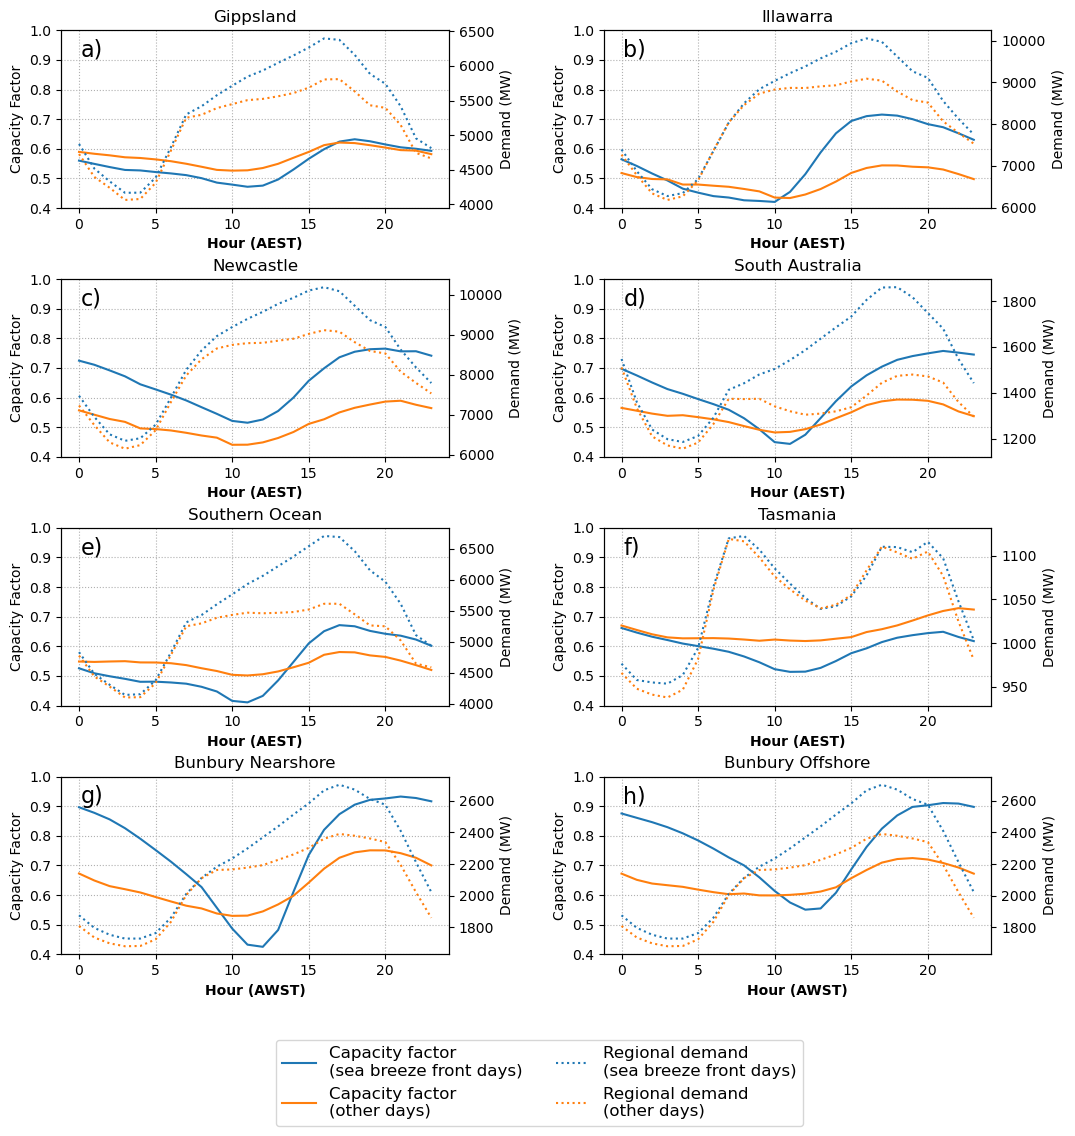

In [17]:
fig=plt.figure(figsize=[12,12])

ax=plt.subplot(4,2,1)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland", letter="a",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,2)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra", demand=demand_nsw, sb_days=illawara_sb_days, letter="b",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,3)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,4)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia", demand=demand_sa, sb_days=sa_sb_days, letter="d",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,5)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean", demand=demand_vic, sb_days=southern_sb_days, letter="e",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,6)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania", sb_days=tas_sb_days, letter="f",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(4,2,7)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore", sb_days=bunbury_sb_days, letter="g",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(4,2,8)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore", sb_days=bunbury_sb_days, letter="h",ylab1=True,ylab2=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')

fig.legend([l1[0],l2[0],l3[0],l4[0]],
           ["Capacity factor\n(sea breeze front days)","Capacity factor\n(other days)","Regional demand\n(sea breeze front days)","Regional demand\n(other days)"],
           loc="lower right", bbox_to_anchor=[0.75,-0.04],ncols=2,fontsize="large")

plt.subplots_adjust(hspace=0.4,wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_sb_days.jpeg",bbox_inches="tight",dpi=300)

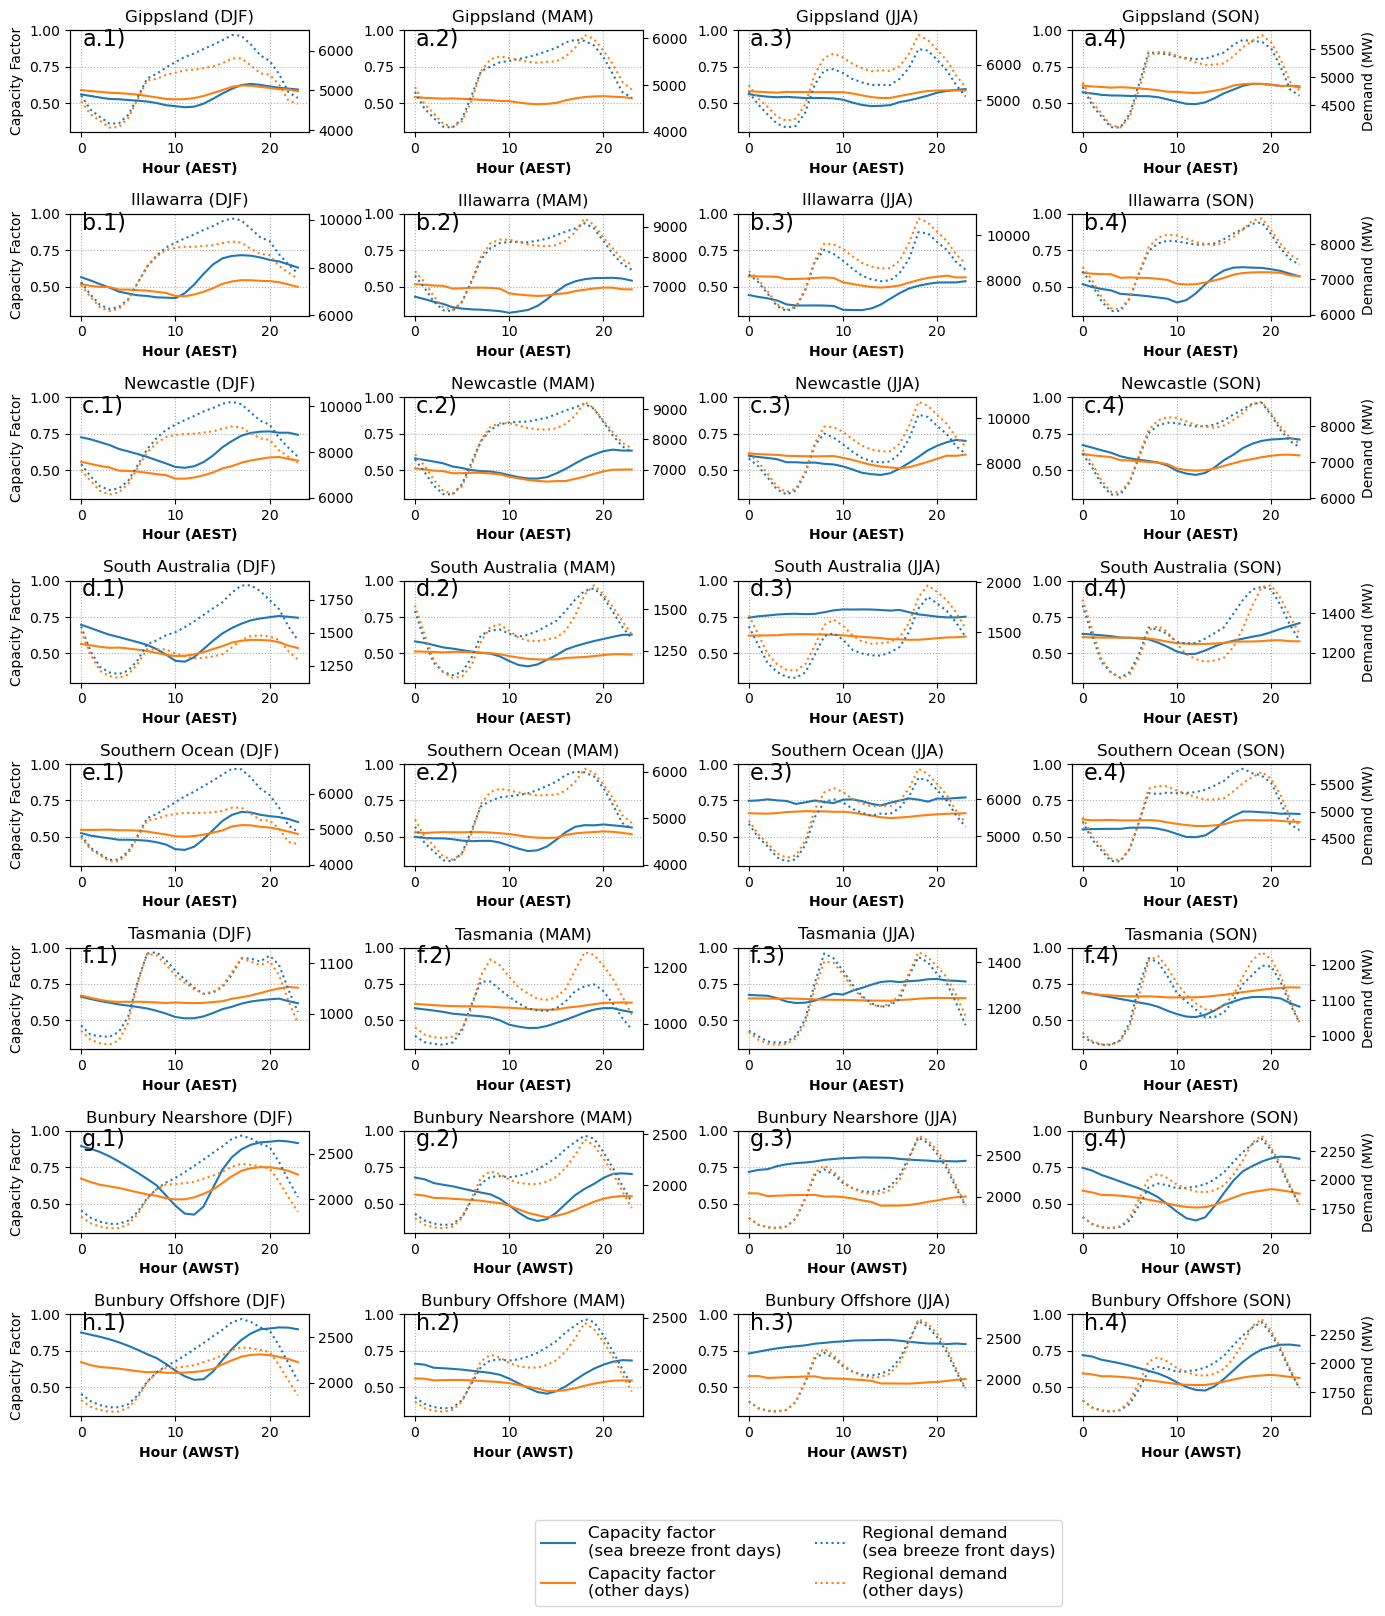

In [18]:
fig=plt.figure(figsize=[16,18])


#GIPPS
ax=plt.subplot(8,4,1)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland (DJF)", letter="a.1", ylab1=True, ylim=[0.3,1])
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,2)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland (MAM)", letter="a.2",season="MAM",ylim=[0.3,1])
ax.set_xlabel("Hour (AEST)", fontweight='bold'); 

ax=plt.subplot(8,4,3)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland (JJA)", letter="a.3",season="JJA",ylim=[0.3,1])
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,4)
plot(shapes["rez_mask"]==27, gipps_sb, gipps_non_sb, "cf", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland (SON)", letter="a.4",season="SON",ylim=[0.3,1], ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')


#ILLAWARRA
ax=plt.subplot(8,4,5)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra (DJF)", demand=demand_nsw, sb_days=illawara_sb_days, letter="b.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,6)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra (MAM)", demand=demand_nsw, sb_days=illawara_sb_days, letter="b.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,7)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra (JJA)", demand=demand_nsw, sb_days=illawara_sb_days, letter="b.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,8)
plot(shapes["rez_mask"]==19, illawarra_sb, illawara_non_sb, "cf",title="Illawarra (SON)", demand=demand_nsw, sb_days=illawara_sb_days, letter="b.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')



#NEWCASTLE
ax=plt.subplot(8,4,9)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle (DJF)", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,10)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle (MAM)", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,11)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle (JJA)", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,12)
plot(shapes["rez_mask"]==18, newcastle_sb, newcastle_non_sb, "cf",title="Newcastle (SON)", demand=demand_nsw, sb_days=newcastle_sb_days, letter="c.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')



#SA
ax=plt.subplot(8,4,13)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia (DJF)", demand=demand_sa, sb_days=sa_sb_days, letter="d.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,14)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia (MAM)", demand=demand_sa, sb_days=sa_sb_days, letter="d.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,15)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia (JJA)", demand=demand_sa, sb_days=sa_sb_days, letter="d.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,16)
plot(shapes["rez_mask"]==38, sa_sb, sa_non_sb, "cf",title="South Australia (SON)", demand=demand_sa, sb_days=sa_sb_days, letter="d.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')


#SOUTHERN OCEAN
ax=plt.subplot(8,4,17)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean (DJF)", demand=demand_vic, sb_days=southern_sb_days, letter="e.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,18)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean (MAM)", demand=demand_vic, sb_days=southern_sb_days, letter="e.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,19)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean (JJA)", demand=demand_vic, sb_days=southern_sb_days, letter="e.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,20)
plot(shapes["rez_mask"]==28, southern_sb, southern_non_sb, "cf",title="Southern Ocean (SON)", demand=demand_vic, sb_days=southern_sb_days, letter="e.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')


#TASMANIA
ax=plt.subplot(8,4,21)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania (DJF)", sb_days=tas_sb_days, letter="f.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,22)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania (MAM)", sb_days=tas_sb_days, letter="f.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,23)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania (JJA)", sb_days=tas_sb_days, letter="f.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AEST)", fontweight='bold')

ax=plt.subplot(8,4,24)
l1,l2,l3,l4=plot(shapes["rez_mask"]==42, tas_sb, tas_non_sb, "cf", demand=demand_tas, title="Tasmania (SON)", sb_days=tas_sb_days, letter="f.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AEST)", fontweight='bold')



#BUNBURY NEARSHORE
ax=plt.subplot(8,4,25)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore (DJF)", sb_days=bunbury_sb_days, letter="g.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,26)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore (MAM)", sb_days=bunbury_sb_days, letter="g.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,27)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore (JJA)", sb_days=bunbury_sb_days, letter="g.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,28)
plot(shapes_bunbury["rez_mask"]==43, bunbury_sb, bunbury_non_sb, "cf", demand=demand_wa, title="Bunbury Nearshore (SON)", sb_days=bunbury_sb_days, letter="g.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')


#BUNBURY OFFSHORE
ax=plt.subplot(8,4,29)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore (DJF)", sb_days=bunbury_sb_days, letter="h.1",ylim=[0.3,1], ylab1=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,30)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore (MAM)", sb_days=bunbury_sb_days, letter="h.2",ylim=[0.3,1], ylab1=False, season="MAM")
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,31)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore (JJA)", sb_days=bunbury_sb_days, letter="h.3",ylim=[0.3,1], ylab1=False, season="JJA")
ax.set_xlabel("Hour (AWST)", fontweight='bold')

ax=plt.subplot(8,4,32)
plot(shapes_bunbury["rez_mask"]==44, bunbury_sb, bunbury_non_sb, "cf",demand=demand_wa, title="Bunbury Offshore (SON)", sb_days=bunbury_sb_days, letter="h.4",ylim=[0.3,1], ylab1=False, season="SON", ylab2=True)
ax.set_xlabel("Hour (AWST)", fontweight='bold')

fig.legend([l1[0],l2[0],l3[0],l4[0]],
           ["Capacity factor\n(sea breeze front days)","Capacity factor\n(other days)","Regional demand\n(sea breeze front days)","Regional demand\n(other days)"],
           loc="lower right", bbox_to_anchor=[0.75,0],ncols=2,fontsize="large")

plt.subplots_adjust(hspace=0.8,wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_sb_days_seasonal.jpeg",bbox_inches="tight",dpi=300)

In [19]:
mask = shapes_bunbury["rez_mask"]==43

season = "DJF" 

sb = bunbury_sb

non_sb = bunbury_non_sb

var = "cf"

print(
    xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).rename(var).to_dataframe(),
    xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).rename(var).to_dataframe()
)

      crs       time  region abbrevs                    names season        cf
hour                                                                          
0       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.896652
1       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.877802
2       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.855632
3       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.825968
4       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.790417
5       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.752175
6       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.712953
7       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.670820
8       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.627114
9       0 2024-12-01      42     r42  T4 North Tasmania Coast    DJF  0.557098
10      0 2024-12-01      42     r42  T4 North Tasma

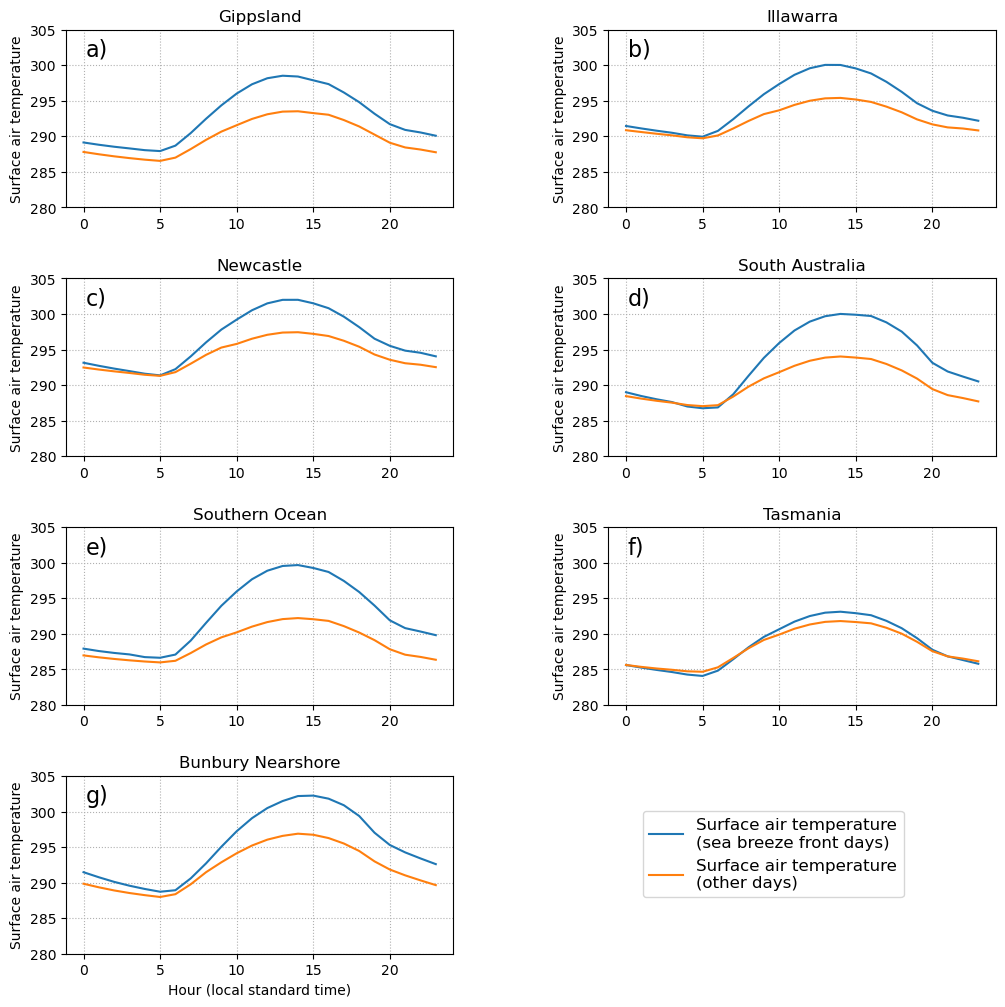

In [20]:
def plot(mask,sb,non_sb,var,season="DJF",title="",demand=None,sb_days=None,letter=""):
    l1=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:blue")
    l2=xr.where(
        mask,
        non_sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(color="tab:orange")
    plt.title(title)

    if var=="u":
        plt.ylim([-7,7])
    elif var=="v":
        plt.ylim([-12,12])
    elif var=="cf":
        plt.ylim([0.4,1])
    elif var=="tas":
        plt.ylim([280,305])

    plt.xlabel("")
    plt.gca().grid(ls=":")
    plt.ylabel("Surface air temperature")

    plt.gca().text(0.05,0.85,letter+")",transform=plt.gca().transAxes,fontdict={"size":"16"})

    return l1,l2

fig=plt.figure(figsize=[12,12])

plt.subplot(4,2,1)
plot(shapes.gipps, gipps_sb, gipps_non_sb, "tas", demand=demand_vic, sb_days=gipps_sb_days, title="Gippsland",letter="a")

plt.subplot(4,2,2)
plot(shapes.illawara, illawarra_sb, illawara_non_sb, "tas",title="Illawarra", demand=demand_nsw, sb_days=illawara_sb_days,letter="b")

plt.subplot(4,2,3)
plot(shapes.newcastle, newcastle_sb, newcastle_non_sb, "tas",title="Newcastle", demand=demand_nsw, sb_days=newcastle_sb_days,letter="c")

plt.subplot(4,2,4)
plot(shapes.sa, sa_sb, sa_non_sb, "tas",title="South Australia", demand=demand_sa, sb_days=sa_sb_days,letter="d")

plt.subplot(4,2,5)
plot(shapes.southern, southern_sb, southern_non_sb, "tas",title="Southern Ocean", demand=demand_vic, sb_days=southern_sb_days,letter="e")

plt.subplot(4,2,6)
l1,l2=plot(shapes.tas, tas_sb, tas_non_sb, "tas", demand=demand_tas, title="Tasmania", sb_days=tas_sb_days,letter="f")

ax=plt.subplot(4,2,7)
plot(shapes_bunbury.bunbury, bunbury_sb, bunbury_non_sb, "tas", demand=demand_wa, title="Bunbury Nearshore", sb_days=bunbury_sb_days,letter="g")
ax.set_xlabel("Hour (local standard time)")

# ax=plt.subplot(4,2,8)
# plot(shapes.bu, bunbury_sb, bunbury_non_sb, "tas",demand=demand_wa, title="Bunbury Offshore", sb_days=bunbury_sb_days)
# ax.set_xlabel("Hour (local standard time)")

fig.legend([l1[0],l2[0],l3[0],l4[0]],
           ["Surface air temperature\n(sea breeze front days)","Surface air temperature\n(other days)"],
           loc="lower right", bbox_to_anchor=[0.83,.15],ncols=1,fontsize="large")

plt.subplots_adjust(hspace=0.4,wspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/tas_sb_days.jpeg",bbox_inches="tight",dpi=300)

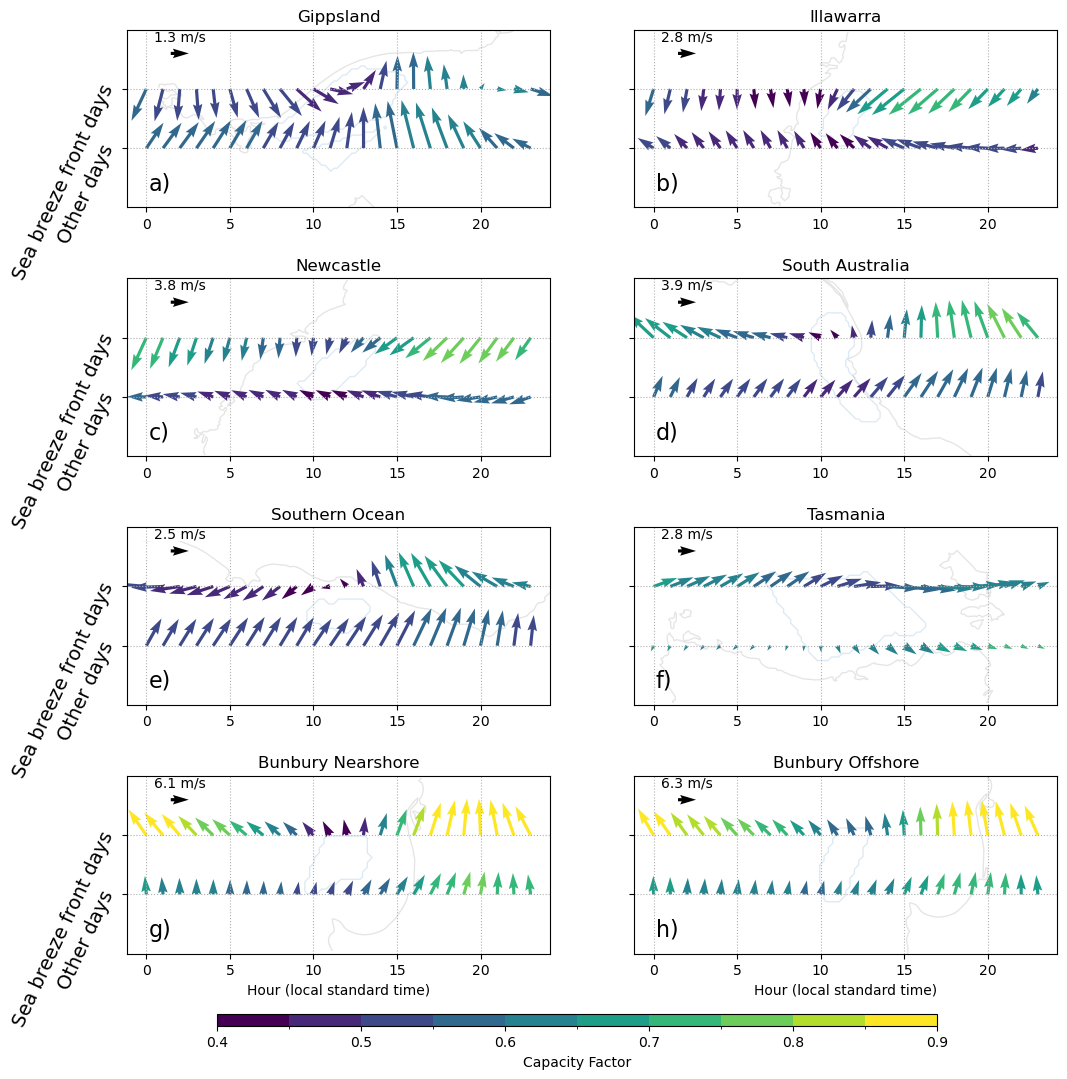

In [21]:
def plot_comp_quiver(mask,temp_sb,temp_non_sb,ax,add_yticklabels=True,title="",letter=""):


    xx,yy = np.meshgrid(mask.lon,mask.lat)
    lon = [xr.where(mask,xx,np.nan).min() - 1.5, xr.where(mask,xx,np.nan).max() + 1.5]
    lat = [xr.where(mask,yy,np.nan).min() - 0.5, xr.where(mask,yy,np.nan).max() + 0.5]
    
    temp_sb = xr.merge([temp_sb,xr.DataArray(np.array([0]*24),dims=["hour"]).rename("y")])
    temp_sb = xr.where(
            mask,
            temp_sb,
            np.nan).mean(("lat","lon"))
    
    
    temp_non_sb = xr.merge([temp_non_sb,xr.DataArray(np.array([-1]*24),dims=["hour"]).rename("y")])
    temp_non_sb = xr.where(
            mask,
            temp_non_sb,
            np.nan).mean(("lat","lon"))

    scale = np.sqrt(temp_sb.u.values**2 + temp_sb.v.values**2).mean() / 1.5
    
    plot_quiver(temp_sb,ax,s=scale)
    Q=plot_quiver(temp_non_sb,ax,add_key=True,s=scale,u_qk=scale)
    
    ax.set_ylim([-2,1])
    ax.set_title("")

    if add_yticklabels:
        ax.set_yticks([-1,0],["Other days","Sea breeze front days"],rotation=65,size=14)
    else:
        ax.set_yticks([-1,0],["",""])
    
    ax2 = ax.inset_axes([0,0,1,1],zorder=0,projection=ccrs.PlateCarree())
    ax2.set_xlim(lon)
    ax2.set_ylim(lat)
    ax2.coastlines(alpha=0.1,color="k")
    xr.plot.contour(mask, ax=ax2, colors=["tab:blue"], linewidths=1, levels=1,alpha=0.15)
    ax2.set_title("")
    ax2.set_axis_off()

    ax.grid(ls=":")

    ax.text(0.05,0.1,letter+")",transform=ax.transAxes,fontdict={"size":"16"})

    plt.title(title)

    return Q

def plot_quiver(temp,ax,s=4,add_key=False,u_qk=1):

    from matplotlib.colors import BoundaryNorm
    
    x = temp.hour
    y = temp.y
    u = temp.u
    v = temp.v
    c = temp.cf
    
    cmap = plt.get_cmap("viridis")
    
    boundaries = np.arange(0.4,0.95,0.05)
    norm = BoundaryNorm(boundaries, ncolors=256, clip=True)
    Q=ax.quiver(x,y,u,v,c,norm=norm,cmap=cmap,scale=s,units="xy")
    if add_key:
        plt.quiverkey(Q,2,0.6,u_qk,label=str(np.round(u_qk,1))+" m/s",coordinates="data")
    return Q

fig=plt.figure(figsize=[12,12])

plot_comp_quiver(shapes["rez_mask"]==27, gipps_sb.sel(season="DJF"), gipps_non_sb.sel(season="DJF"), plt.subplot(4,2,1),title="Gippsland",letter="a")
plot_comp_quiver(shapes["rez_mask"]==19, illawarra_sb.sel(season="DJF"), illawara_non_sb.sel(season="DJF"), plt.subplot(4,2,2),add_yticklabels=False,title="Illawarra",letter="b")
plot_comp_quiver(shapes["rez_mask"]==18, newcastle_sb.sel(season="DJF"), newcastle_non_sb.sel(season="DJF"), plt.subplot(4,2,3),title="Newcastle",letter="c")
plot_comp_quiver(shapes["rez_mask"]==38, sa_sb.sel(season="DJF"), sa_non_sb.sel(season="DJF"), plt.subplot(4,2,4),add_yticklabels=False,title="South Australia",letter="d")
plot_comp_quiver(shapes["rez_mask"]==28, southern_sb.sel(season="DJF"), southern_non_sb.sel(season="DJF"), plt.subplot(4,2,5),title="Southern Ocean",letter="e")
plot_comp_quiver(shapes["rez_mask"]==42, tas_sb.sel(season="DJF"), tas_non_sb.sel(season="DJF"), plt.subplot(4,2,6),add_yticklabels=False,title="Tasmania",letter="f")
plot_comp_quiver(shapes_bunbury["rez_mask"]==43, bunbury_sb.sel(season="DJF"), bunbury_non_sb.sel(season="DJF"), plt.subplot(4,2,7),title="Bunbury Nearshore",letter="g")
plt.xlabel("Hour (local standard time)")
Q = plot_comp_quiver(shapes_bunbury["rez_mask"]==44, bunbury_sb.sel(season="DJF"), bunbury_non_sb.sel(season="DJF"), plt.subplot(4,2,8),add_yticklabels=False,title="Bunbury Offshore",letter="h")
plt.xlabel("Hour (local standard time)")

cb=plt.colorbar(Q,cax=plt.axes([0.2,0.05,0.6,0.01]),orientation="horizontal")
cb.set_label("Capacity Factor")

plt.subplots_adjust(hspace=0.4)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/quiver_sb_days.jpeg",bbox_inches="tight",dpi=300)

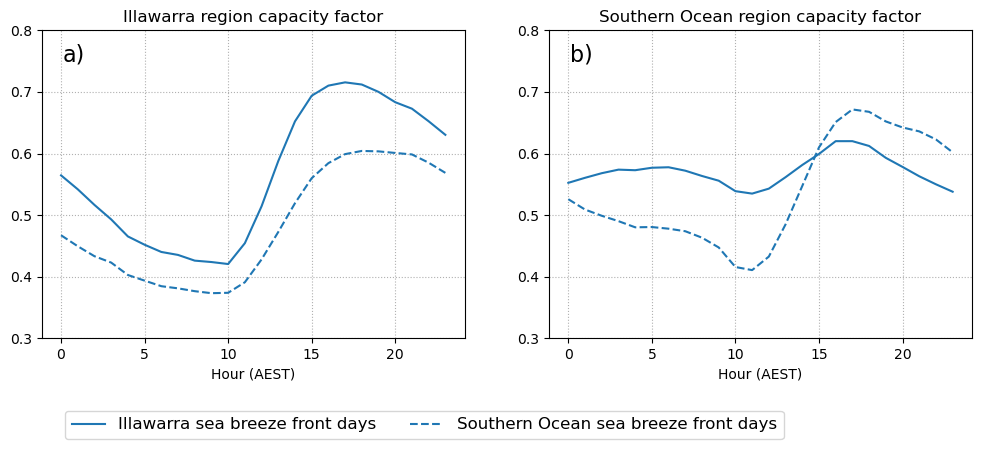

In [22]:
def plot(mask,sb,var,season="DJF",title="",label="",color="tab:blue",ls="-"):
    l=xr.where(
        mask,
        sb.sel(season=season)[var],
        np.nan).mean(("lat","lon")).plot(ls=ls,color=color,add_legend=False)

    if var=="u":
        plt.ylim([-7,7])
    elif var=="v":
        plt.ylim([-12,12])
    elif var=="cf":
        plt.ylim([0.3,0.8])

    plt.gca().grid(ls=":")
    
    return l

fig=plt.figure(figsize=[12,4])

plt.subplot(1,2,1)
l1=plot(shapes["rez_mask"]==19, illawarra_sb, "cf",title="Illawarra",label="Illawarra SBF days",ls="-")
#l2=plot(shapes["rez_mask"]==19, newcastle_sb, "cf",title="Illawarra",label="Newcastle SB days")
#l3=plot(shapes["rez_mask"]==19, gipps_sb, "cf",title="Illawarra",label="Gippsland SB days")
#l4=plot(shapes["rez_mask"]==19, tas_sb, "cf",title="Illawarra",label="Tasmania SB days")
l5=plot(shapes["rez_mask"]==19, southern_sb, "cf",title="Illawarra",label="Southern Ocean SBF days",ls="--")
#l6=plot(shapes["rez_mask"]==19, sa_sb, "cf",title="Illawarra average capacity factor",label="South Australia SB days")
plt.title("Illawarra region capacity factor")
plt.xlabel("Hour (AEST)")
plt.gca().text(0.05,0.9,"a)",transform=plt.gca().transAxes,fontdict={"size":"16"})

plt.subplot(1,2,2)
l1=plot(shapes["rez_mask"]==28, illawarra_sb, "cf",title="",label="Illawarra",ls="-")
#plot(shapes["rez_mask"]==28, newcastle_sb, "cf",title="",label="Newcastle")
#plot(shapes["rez_mask"]==28, gipps_sb, "cf",title="",label="Gippsland")
#plot(shapes["rez_mask"]==28, tas_sb, "cf",title="",label="Tasmania")
l2=plot(shapes["rez_mask"]==28, southern_sb, "cf",title="",label="Southern Ocean",ls="--")
#plot(shapes["rez_mask"]==28, sa_sb, "cf",title="Southern ocean average capacity factor",label="South Australia")
plt.title("Southern Ocean region capacity factor")
plt.xlabel("Hour (AEST)")
plt.gca().text(0.05,0.9,"b)",transform=plt.gca().transAxes,fontdict={"size":"16"})

fig.legend([l1[0],l2[0]],["Illawarra sea breeze front days","Southern Ocean sea breeze front days"],ncols=2,bbox_to_anchor=[0.75,-0.05],fontsize="large")

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_co_occurrence.jpeg",bbox_inches="tight",dpi=300)

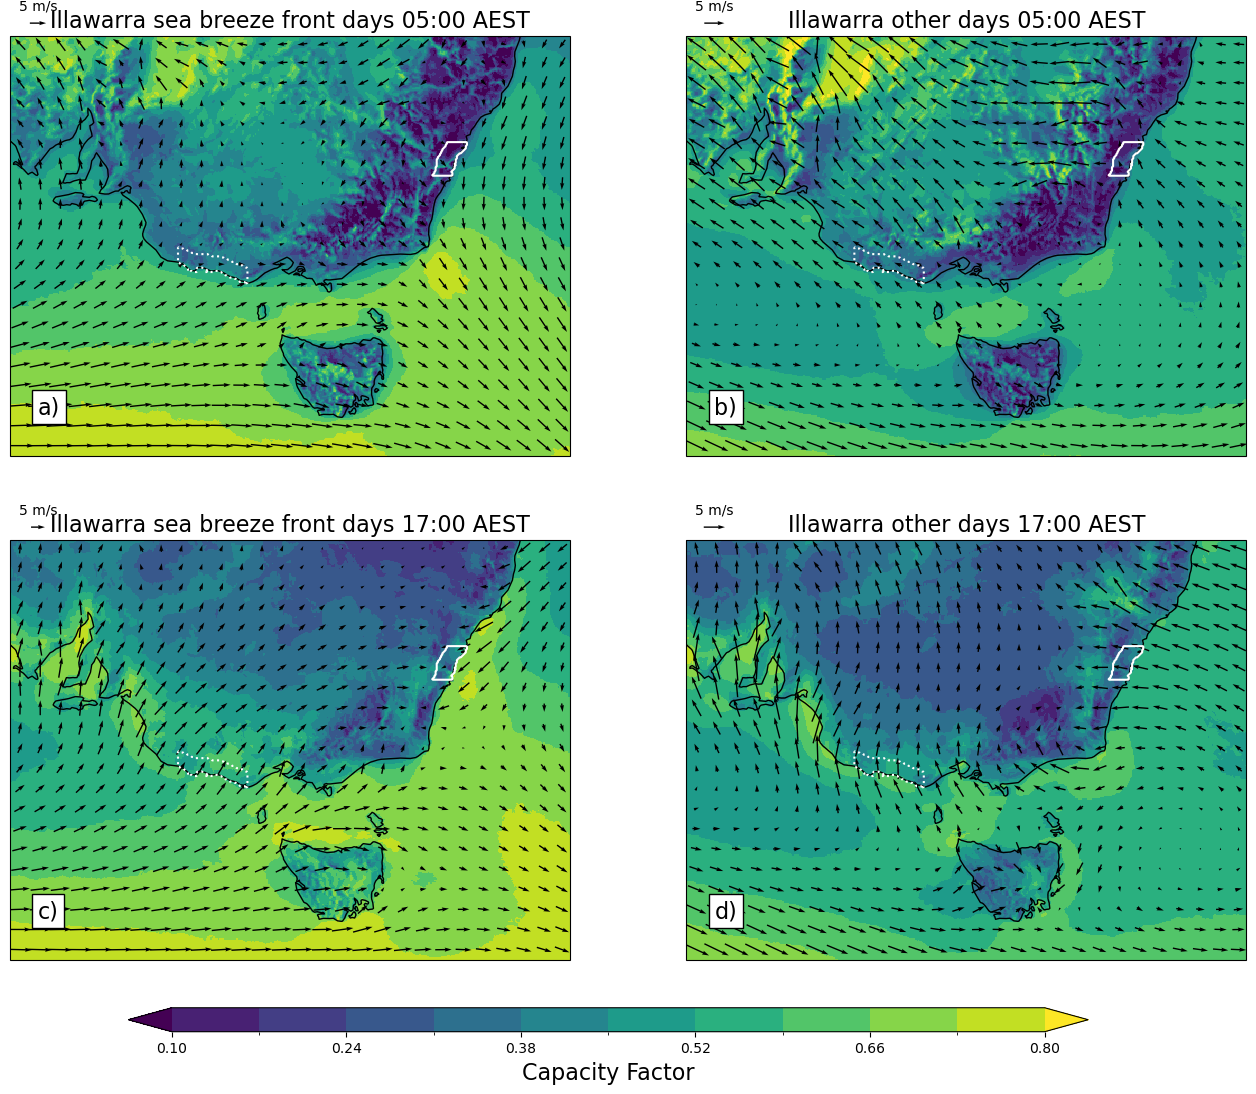

In [23]:
def plot_map(sb_avg,nonsb_avg,h,ax1,ax2,shapes,shape1,shape2,lat_slice=slice(-45,-30),lon_slice=slice(135,155),c=10):

    c=18
    
    if h == "mean":
        sb_avg = sb_avg.mean("hour")
        nonsb_avg = nonsb_avg.mean("hour")
    else:
        sb_avg = sb_avg.sel(hour=h)
        nonsb_avg = nonsb_avg.sel(hour=h)
    
    
    sb_avg.sel(lat=lat_slice,lon=lon_slice).cf.plot(levels=np.linspace(0.1,0.8,11),ax=ax1,extend="both",add_colorbar=False)
    q=sb_avg.sel(lat=lat_slice,lon=lon_slice).coarsen({"lat":c,"lon":c},boundary="pad").mean().plot.quiver(x="lon",y="lat",u="u",v="v",ax=ax1,add_guide=False)
    qk=plt.quiverkey(q,0.05,1.03,5,"5 m/s")
    ax1.coastlines()

    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape1],
            0),
        levels=1,colors=["white"],linewidths=1.5,ax=ax1)
    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape2],
            0),
        levels=1,colors=["white"],linewidths=1.5,linestyles=[":"],ax=ax1)    
    
    p=nonsb_avg.sel(lat=lat_slice,lon=lon_slice).cf.plot(levels=np.linspace(0.1,0.8,11),ax=ax2,extend="both",add_colorbar=False)
    q=nonsb_avg.sel(lat=lat_slice,lon=lon_slice).coarsen({"lat":c,"lon":c},boundary="pad").mean().plot.quiver(x="lon",y="lat",u="u",v="v",ax=ax2,add_guide=False)
    qk=plt.quiverkey(q,0.05,1.03,5,"5 m/s")
    ax2.coastlines()

    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape1],
            0),
        levels=1,colors=["white"],linewidths=1.5,ax=ax2)
    xr.plot.contour(
        xr.where(shapes["lsm"],
                shapes[shape2],
            0),
        levels=1,colors=["white"],linewidths=1.5,linestyles=[":"],ax=ax2)   

    return p


plt.figure(figsize=[16,12])

ax1=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
plot_map(illawarra_sb.sel(season="DJF"),illawara_non_sb.sel(season="DJF"),5,ax1,ax2,shapes,"illawara_landsea","southern_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Illawarra sea breeze front days 05:00 AEST",size=16)
ax2.set_title("Illawarra other days 05:00 AEST",size=16)

ax1.text(0.05,0.1,"a)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"b)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

# c=xr.plot.contourf(
#     xr.where(shapes["rez_mask"].isin([27,19,18,28,38,42,43]),shapes["rez_mask"],np.nan),add_colorbar=False,cmap="tab10",levels=levels)

# c_orog = xr.where(shapes["lsm"],orog.sel(lat=shapes.lat,lon=shapes.lon).orog,np.nan).plot(vmin=0,vmax=1500,cmap="terrain",extend="max",add_colorbar=False)

ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
c=plot_map(illawarra_sb.sel(season="DJF"),illawara_non_sb.sel(season="DJF"),17,ax1,ax2,shapes,"illawara_landsea","southern_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Illawarra sea breeze front days 17:00 AEST",size=16)
ax2.set_title("Illawarra other days 17:00 AEST",size=16)

ax1.text(0.05,0.1,"c)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"d)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Capacity Factor",size=16)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/illawarra_composite_map.jpeg",bbox_inches="tight",dpi=300)

/jobfs/167853285.gadi-pbs/ipykernel_289045/2427301965.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1200 with 5 Axes> than <Figure size 1600x1200 with 5 Axes> which fig.colorbar is called on.
  cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")


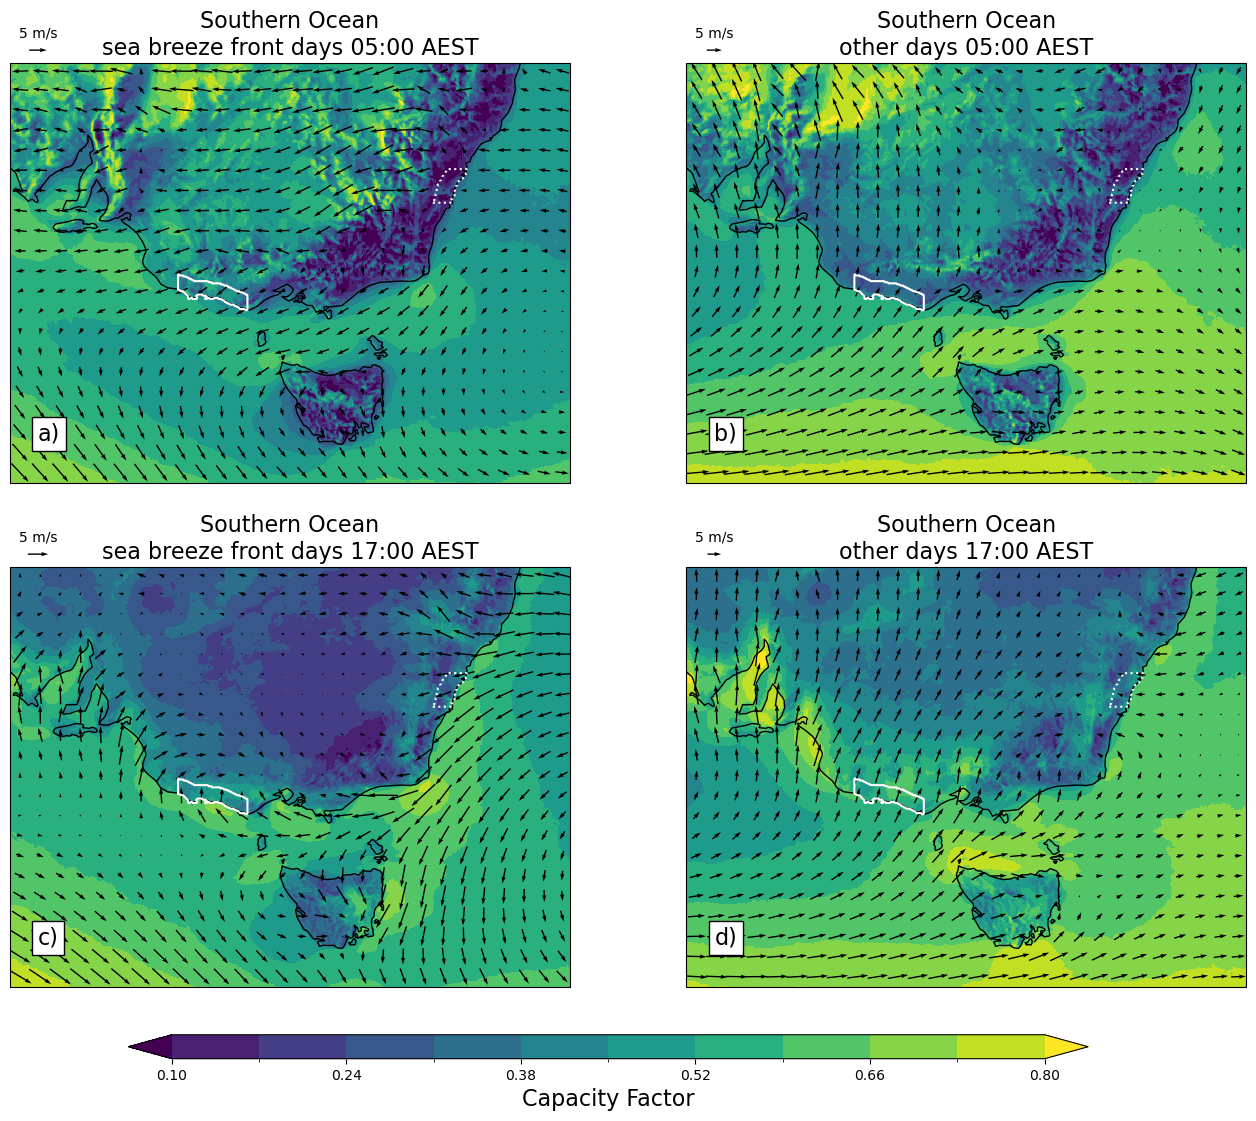

In [27]:
plt.figure(figsize=[16,12])

ax1=plt.subplot(2,2,1,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,2,projection=ccrs.PlateCarree())
plot_map(southern_sb.sel(season="DJF"),southern_non_sb.sel(season="DJF"),5,ax1,ax2,shapes,"southern_landsea","illawara_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Southern Ocean\nsea breeze front days 05:00 AEST",size=16)
ax2.set_title("Southern Ocean\nother days 05:00 AEST",size=16)
ax1.text(0.05,0.1,"a)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"b)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))

ax1=plt.subplot(2,2,3,projection=ccrs.PlateCarree())
ax2=plt.subplot(2,2,4,projection=ccrs.PlateCarree())
plot_map(southern_sb.sel(season="DJF"),southern_non_sb.sel(season="DJF"),17,ax1,ax2,shapes,"southern_landsea","illawara_landsea")#,lat_slice=slice(-42,-27),lon_slice=slice(108,130))
ax1.set_title("Southern Ocean\nsea breeze front days 17:00 AEST",size=16)
ax2.set_title("Southern Ocean\nother days 17:00 AEST",size=16)
ax1.text(0.05,0.1,"c)",transform=ax1.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))
ax2.text(0.05,0.1,"d)",transform=ax2.transAxes,fontdict={"size":"16"},bbox=dict(facecolor='white'))


cb=plt.colorbar(c,cax=plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")
cb.set_label("Capacity Factor",size=16)

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/southern_composite_map.jpeg",bbox_inches="tight",dpi=300)

In [25]:
uname = "ua100m"
vname = "va100m"

files = np.sort(glob.glob("/scratch/ng72/ab4502/hourly_composites/barra_c/barra_c_hourly_"+uname+"_"+vname+"*.nc"))
file_dates = [pd.to_datetime(f.split("/")[-1].split("_")[-2]) for f in files]
file_years = np.array([d.year for d in file_dates])
file_months = np.array([d.month for d in file_dates])

In [26]:
hourly_cf_djf = xr.open_mfdataset(
    files[np.in1d(file_months,[12,1,2])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[12,1,2])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes.lat,lon=shapes.lon).persist()

hourly_cf_jja = xr.open_mfdataset(
    files[np.in1d(file_months,[6,7,8])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[6,7,8])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes.lat,lon=shapes.lon).persist()

hourly_cf_djf["hour"] = (hourly_cf_djf.hour + 10) % 24
hourly_cf_jja["hour"] = (hourly_cf_jja.hour + 10) % 24

OSError: no files to open

In [ ]:
hourly_cf_djf_bunbury = xr.open_mfdataset(
    files[np.in1d(file_months,[12,1,2])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[12,1,2])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes_bunbury.lat,lon=shapes_bunbury.lon).persist()

hourly_cf_jja_bunbury = xr.open_mfdataset(
    files[np.in1d(file_months,[6,7,8])],
    concat_dim=xr.DataArray(np.array(file_dates)[np.in1d(file_months,[6,7,8])],dims="month"),
    combine="nested"
).cf.sel(lat=shapes_bunbury.lat,lon=shapes_bunbury.lon).persist()

hourly_cf_djf_bunbury["hour"] = (hourly_cf_djf_bunbury.hour + 8) % 24
hourly_cf_jja_bunbury["hour"] = (hourly_cf_jja_bunbury.hour + 8) % 24

In [ ]:
hourly_cf_djf = hourly_cf_djf.sortby("hour")
hourly_cf_jja = hourly_cf_jja.sortby("hour")

hourly_cf_djf_bunbury = hourly_cf_djf_bunbury.sortby("hour")
hourly_cf_jja_bunbury = hourly_cf_jja_bunbury.sortby("hour")

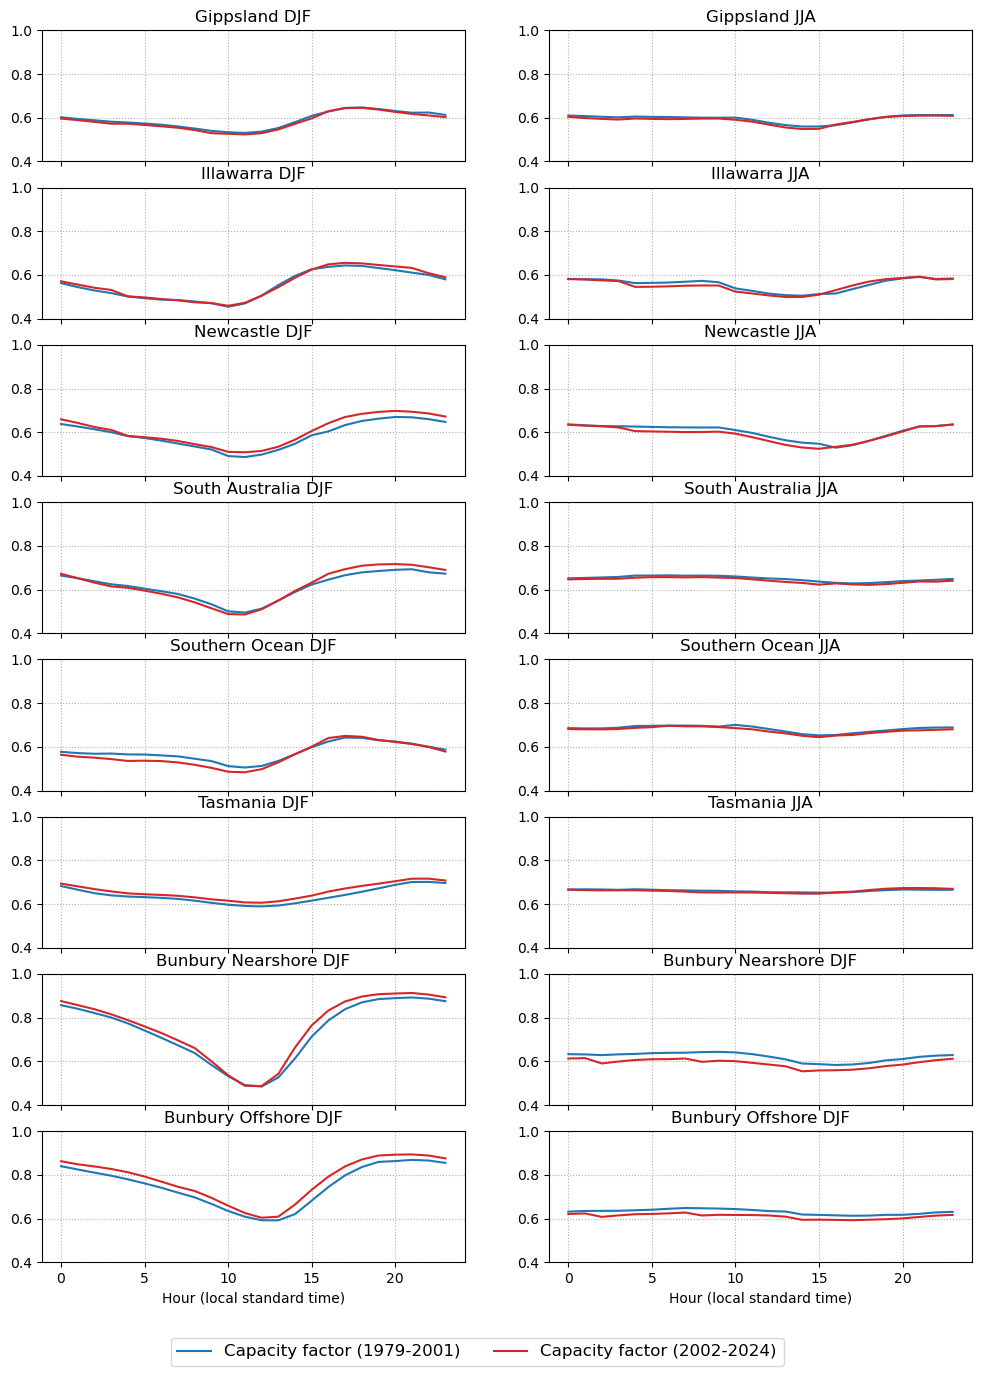

In [22]:
def plot(ax, cf_ds1, cf_ds2, mask, title="", xticklabels=False):

    l1=xr.where(
            mask,
            cf_ds1,
            np.nan).mean(("lat","lon","month")).plot(color="tab:blue")
    
    l2=xr.where(
            mask,
            cf_ds2,
            np.nan).mean(("lat","lon","month")).plot(color="tab:red")
    plt.ylim([0.4,1])
    plt.title(title)

    ax.grid(ls=":")
    ax.set_xlabel("")

    if xticklabels:
        pass
    else:
        ax.set_xticklabels("")

    return l1, l2


fig=plt.figure(figsize=[12,16])


plot(
    plt.subplot(8,2,1),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==27,
    title="Gippsland DJF"
)
plot(
    plt.subplot(8,2,2),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==27,
    title="Gippsland JJA"
)


plot(
    plt.subplot(8,2,3),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==19,
    title="Illawarra DJF"
)
plot(
    plt.subplot(8,2,4),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==19,
    title="Illawarra JJA"
)


plot(
    plt.subplot(8,2,5),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==18,
    title="Newcastle DJF"
)
plot(
    plt.subplot(8,2,6),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==18,
    title="Newcastle JJA"
)


plot(
    plt.subplot(8,2,7),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==38,
    title="South Australia DJF"
)
plot(
    plt.subplot(8,2,8),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==38,
    title="South Australia JJA"
)


plot(
    plt.subplot(8,2,9),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==28,
    title="Southern Ocean DJF"
)
plot(
    plt.subplot(8,2,10),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==28,
    title="Southern Ocean JJA"
)


plot(
    plt.subplot(8,2,11),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year<=2001),
    hourly_cf_djf.sel(month=hourly_cf_djf.month.dt.year>=2002),
    shapes.rez_mask==42,
    title="Tasmania DJF"
)
plot(
    plt.subplot(8,2,12),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year<=2001),
    hourly_cf_jja.sel(month=hourly_cf_jja.month.dt.year>=2002),
    shapes.rez_mask==42,
    title="Tasmania JJA"
)


plot(
    plt.subplot(8,2,13),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year<=2001),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==43,
    title="Bunbury Nearshore DJF"
)
plot(
    plt.subplot(8,2,14),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year<=2001),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==43,
    title="Bunbury Nearshore DJF"
)



plot(
    plt.subplot(8,2,15),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year<=2001),
    hourly_cf_djf_bunbury.sel(month=hourly_cf_djf_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==44,
    title="Bunbury Offshore DJF",
    xticklabels=True
)
plt.xlabel("Hour (local standard time)")

l1,l2=plot(
    plt.subplot(8,2,16),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year<=2001),
    hourly_cf_jja_bunbury.sel(month=hourly_cf_jja_bunbury.month.dt.year>=2002),
    shapes_bunbury.rez_mask==44,
    title="Bunbury Offshore DJF",
    xticklabels=True
)
plt.xlabel("Hour (local standard time)")

fig.legend([l1[0],l2[0]],
           ["Capacity factor (1979-2001)","Capacity factor (2002-2024)"],
           loc="lower right", bbox_to_anchor=[0.75,0.04],ncols=2,fontsize="large")

plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/cf_diurnal_trend.jpeg",bbox_inches="tight",dpi=300)